In [16]:
import sys
sys.path.append('code')
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

from scipy.stats import spearmanr,pearsonr
from scipy.stats import pearsonr, spearmanr
from scipy.stats import mannwhitneyu,ttest_ind
from scipy.stats import gaussian_kde

In [3]:
def z_norm(header: dict, values: np.ndarray) -> np.ndarray:
    required_keys = {"sumData", "sumSquared", "nBasesCovered"}
    if not required_keys.issubset(header.keys()):
        raise ValueError(f"Header 必须包含键: {required_keys}")
    n = header["nBasesCovered"]
    if n == 0:
        raise ValueError("nBasesCovered 为 0，无法计算均值和标准差")
    mean = header["sumData"] / n
    mean_sq = header["sumSquared"] / n
    variance = max(mean_sq - mean**2, 0.0)
    std = np.sqrt(variance)
    if std == 0:
        raise ValueError("标准差为 0，无法进行 Z 标准化")
    return (values - mean) / std

def sigmoid_norm(x,p1=[0.3,0.3],p2=[0.7,0.7]):
    x1,y1 = p1;x2,y2 = p2
    k = ( np.log(1/y1-1)-np.log(1/y2-1) ) / ( x2-x1 )
    b = np.log(1/y1-1)+k*x1
    
    x = np.array(x)
    return 1/(1+np.exp(-k*x+b))

def Logistic_norm(x, px=[0, 2.0, 4.0, 6.0], py=[0.0, 0.5, 0.8, 1.0]):
    x = np.asarray(x)
    return PchipInterpolator(px, py)(x)

def sliding_average(y, k, mode='valid'):
    y = np.asarray(y)
    window = np.ones(k) / k
    smoothed = np.convolve(y, window, mode=mode)
    return smoothed

def draw_transcript(
    ax,gene_df,x_lim=(0, 10000),y_lim=(2.0, 12.0),interval_base=64,intron_linewidth=1.0,gene_font_size=12,arrow_font_size=10,
):
    """
    ax            : matplotlib.axes.Axes
    gene_df       : 已整理好的基因表格（包含 gene_name, start, end, strand）
    x_lim         : (start, end)，真实绘图区间
    y_lim         : y 轴范围，默认 (2.0, 12.0)
    interval_base : 箭头间隔基数，默认 64
    """

    start, end = x_lim
    y_min, y_max = y_lim

    # ====== y 轴自动缩放因子 ======
    default_y_span = 12.0 - 2.0   # 你原始设计的高度
    current_y_span = y_max - y_min
    y_scale = current_y_span / default_y_span

    rect_height = 1.0 * y_scale
    flag_step = 2.0 * y_scale
    text_offset = 1.0 * y_scale

    # ====== 初始 flag（保持你原逻辑的“从上往下堆”） ======
    flag = y_max - 2.0 * y_scale

    interval = (end - start) // interval_base

    # ====== 主绘制逻辑 ======
    for gene, group in gene_df.groupby('gene_name', sort=False):
        strand = group.iloc[0]['strand']

        # ---- 外显子矩形 ----
        for rw in group.itertuples():
            rect = patches.Rectangle(
                (rw.start, flag),
                rw.end - rw.start,
                rect_height,
                edgecolor=None,
                facecolor='#57606f',
                alpha=1.0,
                linewidth=1.5
            )
            ax.add_patch(rect)

        # ---- 内含子线 ----
        ax.plot(
            [group['start'].min(), group['end'].max()],
            [flag + rect_height / 2, flag + rect_height / 2],
            color='b',linewidth=intron_linewidth
        )

        # ---- 链方向箭头（完全沿用你的裁切逻辑） ----
        if strand == '+':
            for x in range(
                min(
                    group['start'].min() + interval,
                    (group['start'].min() + group['end'].max()) // 2
                ),
                group['end'].max(),
                interval
            ):
                if x > min(end, group['end'].max()):
                    continue
                if x < max(start, group['start'].min()):
                    continue
                ax.text(x, flag + rect_height / 2, '>',
                        va='center', ha='center',
                        fontsize=arrow_font_size, color='b')
        else:
            for x in range(
                max(
                    (group['start'].min() + group['end'].max()) // 2,
                    group['end'].max() - interval
                ),
                group['start'].min(),
                -interval
            ):
                if x > min(end, group['end'].max()):
                    continue
                if x < max(start, group['start'].min()):
                    continue
                ax.text(x, flag + rect_height / 2, '<',
                        va='center', ha='center',
                        fontsize=arrow_font_size, color='b')

        # ---- 基因名标注（逻辑 100% 保留） ----
        if not (group['end'].max() <= start or group['start'].min() >= end):
            center = (group['start'].min() + group['end'].max()) // 2

            if center < start:
                label_x = (start + group['end'].max()) // 2
            elif center > end:
                label_x = (group['start'].min() + end) // 2
            else:
                label_x = center

            ax.text(
                label_x,
                flag + text_offset,
                gene,
                va='bottom',
                ha='center',
                fontsize=gene_font_size
            )

        # ---- flag 递减 & 回绕 ----
        flag -= flag_step
        if flag <= y_min:
            flag = y_max - 2.0 * y_scale

    # ====== 坐标轴设置 ======
    ax.set_xlim(start, end)
    ax.set_ylim(y_min, y_max)

# Figure 4b

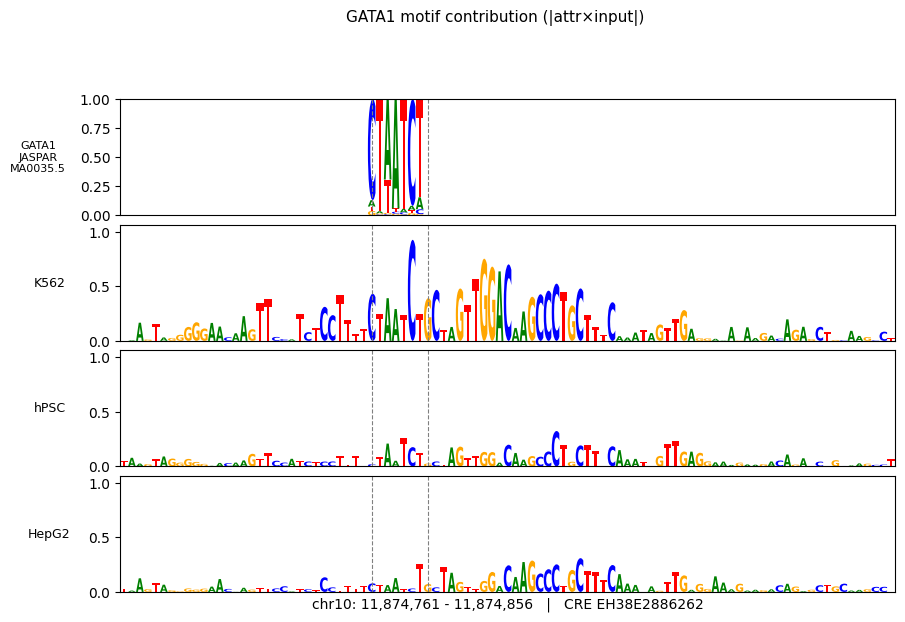

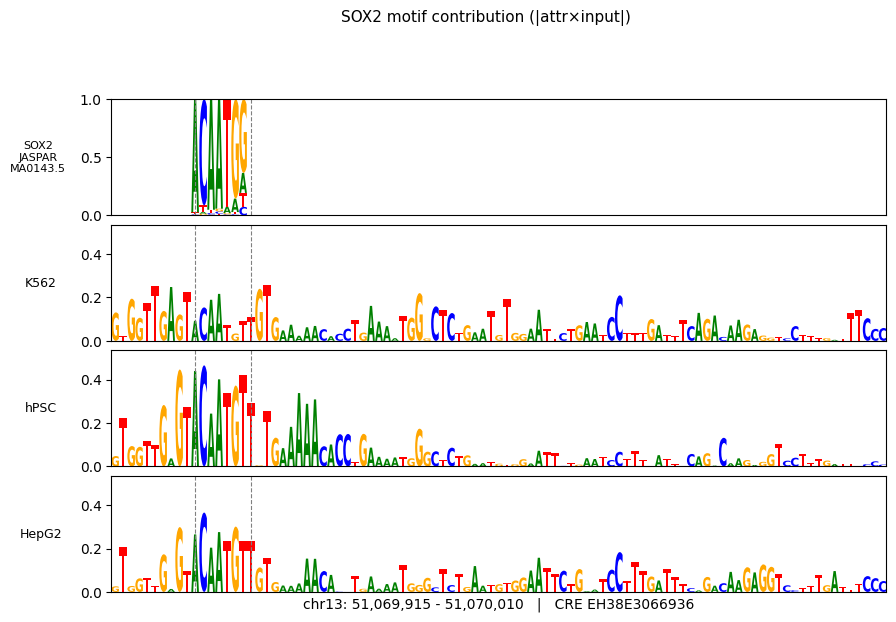

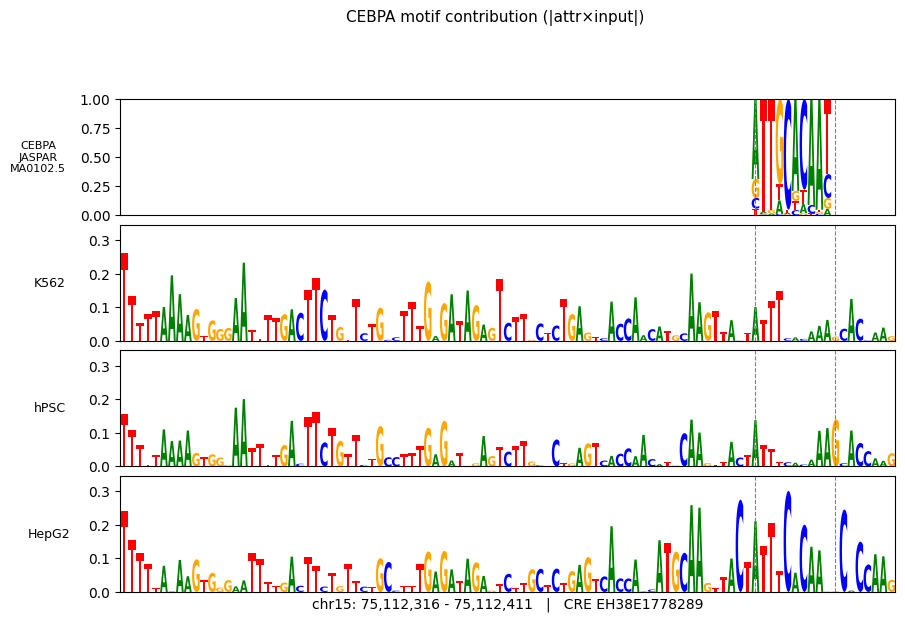

In [5]:
import pickle
from pathlib import Path
import logomaker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
with open('data/fig4/fig4b_preprocessed.pkl', 'rb') as f:
    fig4b_data = pickle.load(f)
CELL_LINES = ('K562', 'hPSC', 'HepG2')
colors = {'K562': '#e41a1c', 'hPSC': '#377eb8', 'HepG2': '#4daf4a'}
for entry in fig4b_data.values():
    tf = entry['tf']
    cid = entry['cre_id']
    logo_dfs = entry['logo_dfs']
    pwm_padded = entry['pwm_padded']
    ymax = entry['ymax']
    mb = entry['motif_begin_win']
    ms = entry['motif_stop_win']
    n_rows = 1 + len(logo_dfs)
    fig, axes = plt.subplots(
        n_rows, 1, figsize=(10, 1.6 * n_rows),
        sharex=True, gridspec_kw={'hspace': 0.08}
    )
    if n_rows == 1:
        axes = [axes]
    ax_ref = axes[0]
    logomaker.Logo(pwm_padded, ax=ax_ref, color_scheme='classic')
    ax_ref.set_ylabel(f"{tf}\nJASPAR\n{entry['jaspar_id']}",
                      fontsize=8, rotation=0, labelpad=30, va='center')
    ax_ref.set_xticks([])
    ax_ref.set_ylim(bottom=0)
    ax_ref.axvline(mb, color='gray', ls='--', lw=0.8)
    ax_ref.axvline(ms, color='gray', ls='--', lw=0.8)
    for ax, cl in zip(axes[1:], [c for c in CELL_LINES if c in logo_dfs]):
        df = logo_dfs[cl]
        logomaker.Logo(df, ax=ax, color_scheme='classic')
        ax.set_ylabel(cl, fontsize=9, rotation=0, labelpad=28, va='center')
        ax.set_ylim(0, ymax)
        ax.axvline(mb, color='gray', ls='--', lw=0.8)
        ax.axvline(ms, color='gray', ls='--', lw=0.8)
    coord = f"{entry['chr']}: {entry['display_start']:,} - {entry['display_end']:,}"
    axes[-1].set_xlabel(f"{coord}   |   CRE {cid}")
    fig.suptitle(f"{tf} motif contribution (|attr×input|)", fontsize=11, y=1.02)
    pdf_path = Path(f'figures/fig1_{tf}_{cid}.pdf')
    fig.savefig(pdf_path, dpi=150, bbox_inches='tight')
    plt.savefig('figures/Fig4b_motif_logo.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Figure 4c

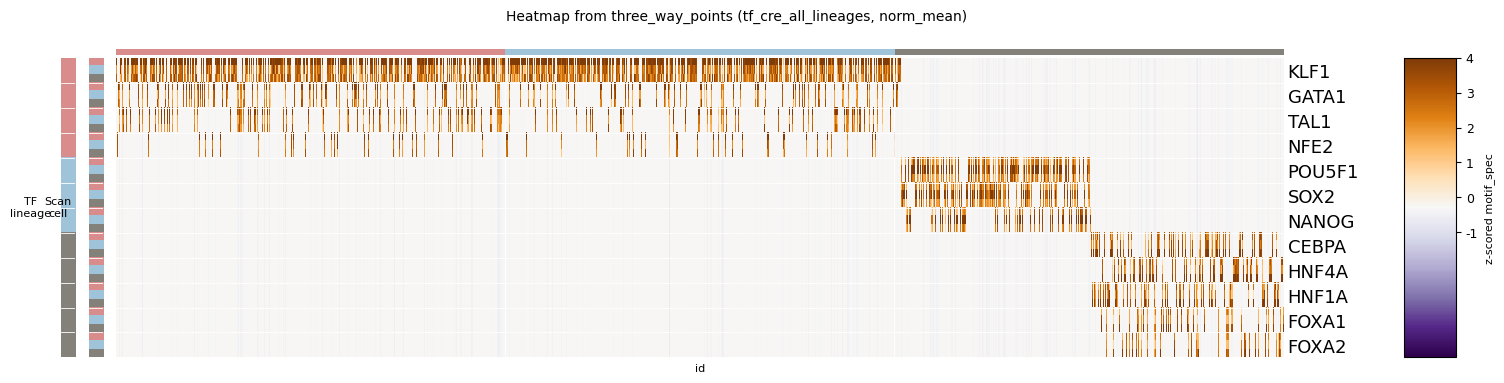

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
file_path = "data/fig4/heatmap_boxplot_points_norm_mean_tf_cre_all_lineages_matrix_zscore.csv"
outdir = "figures/fig4_motif_pdf_style/"
os.makedirs(outdir, exist_ok=True)
cell_order = ["K562", "hPSC", "HepG2"]
cell_color_dict = {
    "K562": "#D98C8C",
    "hPSC": "#9FC3D9",
    "HepG2": "#84817a",
}
tf_lineage_dict = {
    "KLF1": "K562",
    "GATA1": "K562",
    "TAL1": "K562",
    "NFE2": "K562",
    "POU5F1": "hPSC",
    "SOX2": "hPSC",
    "NANOG": "hPSC",
    "CEBPA": "HepG2",
    "HNF4A": "HepG2",
    "HNF1A": "HepG2",
    "FOXA1": "HepG2",
    "FOXA2": "HepG2",
}
tf_order = list(tf_lineage_dict.keys())
df = pd.read_csv(file_path)
df = df.set_index(df.columns[0])
df = df.apply(pd.to_numeric, errors="coerce")
desired_rows = []
for tf in tf_order:
    for ct in cell_order:
        row = f"{tf}|{ct}"
        if row in df.index:
            desired_rows.append(row)
remaining_rows = [r for r in df.index if r not in desired_rows]
df = df.loc[desired_rows + remaining_rows]
def get_tf_from_row(row):
    return row.split("|")[0]
def get_ct_from_row(row):
    return row.split("|")[1]
row_tf = pd.Series(df.index, index=df.index).map(get_tf_from_row)
row_scan_ct = pd.Series(df.index, index=df.index).map(get_ct_from_row)
cell_to_id = {ct: i for i, ct in enumerate(cell_order)}
row_tf_lineage = row_tf.map(tf_lineage_dict)
tf_lineage_ids = row_tf_lineage.map(cell_to_id).values
scan_cell_ids = row_scan_ct.map(cell_to_id).values
n_cols = df.shape[1]
block_size = n_cols // 3
col_lineage = []
for i in range(n_cols):
    if i < block_size:
        col_lineage.append("K562")
    elif i < block_size * 2:
        col_lineage.append("hPSC")
    else:
        col_lineage.append("HepG2")
col_color_ids = np.array([cell_to_id[ct] for ct in col_lineage])
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"
cell_cmap = ListedColormap([cell_color_dict[ct] for ct in cell_order])
heat_cmap = "PuOr_r"
fig = plt.figure(figsize=(18, 4))
gs = fig.add_gridspec(
    nrows=2,
    ncols=5,
    width_ratios=[0.12, 0.12, 10, 0.8, 0.45],
    height_ratios=[0.18, 10],
    wspace=0.05,
    hspace=0.02
)
ax_top = fig.add_subplot(gs[0, 2])
ax_left_tf = fig.add_subplot(gs[1, 0])
ax_left_scan = fig.add_subplot(gs[1, 1])
ax_heat = fig.add_subplot(gs[1, 2])
ax_cbar = fig.add_subplot(gs[1, 4])
ax_top.imshow(
    col_color_ids.reshape(1, -1),
    aspect="auto",
    cmap=cell_cmap,
    interpolation="nearest",
    vmin=0,
    vmax=len(cell_order) - 1
)
ax_top.set_xticks([])
ax_top.set_yticks([])
for spine in ax_top.spines.values():
    spine.set_visible(False)
ax_left_tf.imshow(
    tf_lineage_ids.reshape(-1, 1),
    aspect="auto",
    cmap=cell_cmap,
    interpolation="nearest",
    vmin=0,
    vmax=len(cell_order) - 1
)
ax_left_tf.set_xticks([])
ax_left_tf.set_yticks([])
for spine in ax_left_tf.spines.values():
    spine.set_visible(False)
ax_left_tf.set_ylabel(
    "TF\nlineage",
    fontsize=8,
    rotation=0,
    labelpad=22,
    va="center"
)
ax_left_scan.imshow(
    scan_cell_ids.reshape(-1, 1),
    aspect="auto",
    cmap=cell_cmap,
    interpolation="nearest",
    vmin=0,
    vmax=len(cell_order) - 1
)
ax_left_scan.set_xticks([])
ax_left_scan.set_yticks([])
for spine in ax_left_scan.spines.values():
    spine.set_visible(False)
ax_left_scan.set_ylabel(
    "Scan\ncell",
    fontsize=8,
    rotation=0,
    labelpad=22,
    va="center"
)
im = ax_heat.imshow(
    df.values,
    cmap=heat_cmap,
    aspect="auto",
    interpolation="nearest",
    vmin=-4.6,
    vmax=4
)
ax_heat.set_xticks([])
ax_heat.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)
yticks = []
yticklabels = []
for tf in tf_order:
    positions = np.where(row_tf.values == tf)[0]
    if len(positions) > 0:
        center = positions.mean()
        yticks.append(center)
        yticklabels.append(tf)
ax_heat.set_yticks(yticks)
ax_heat.set_yticklabels(yticklabels, fontsize=13)
ax_heat.yaxis.tick_right()
ax_heat.yaxis.set_label_position("right")
ax_heat.tick_params(
    axis="y",
    length=0,
    pad=3
)
for spine in ax_heat.spines.values():
    spine.set_visible(False)
ax_heat.set_xlabel("id", fontsize=8)
boundary = 0
for tf in tf_order[:-1]:
    n = sum(row_tf == tf)
    boundary += n
    ax_heat.axhline(
        boundary - 0.5,
        color="white",
        linewidth=0.6
    )
    ax_left_tf.axhline(
        boundary - 0.5,
        color="white",
        linewidth=0.6
    )
    ax_left_scan.axhline(
        boundary - 0.5,
        color="white",
        linewidth=0.6
    )
for x in [block_size, block_size * 2]:
    ax_heat.axvline(
        x - 0.5,
        color="white",
        linewidth=0.6
    )
cbar = plt.colorbar(
    im,
    cax=ax_cbar
)
cbar.set_ticks([-1, 0, 1, 2, 3, 4])
cbar.set_ticklabels(['-1', '0', '1', '2', '3', '4'])
cbar.set_label(
    "z-scored motif_spec",
    fontsize=8
)
cbar.ax.tick_params(labelsize=9)
fig.suptitle(
    "Heatmap from three_way_points (tf_cre_all_lineages, norm_mean)",
    fontsize=10,
    y=0.98
)
pdf_out = os.path.join(outdir, "heatmap_pdf_style_two_left_bars.pdf")
plt.savefig(pdf_out, bbox_inches="tight")
plt.show()


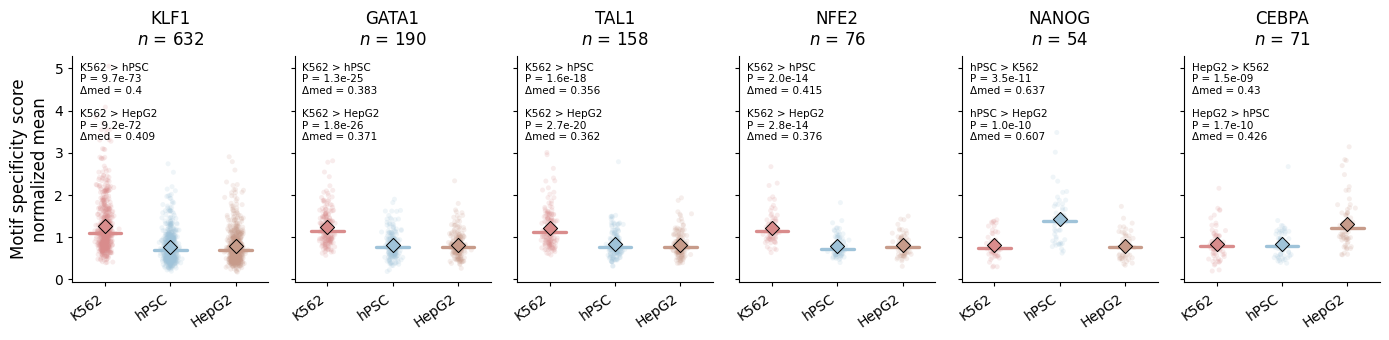

In [8]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
matplotlib.rcParams.update({
    "font.family": "Dejavu Sans",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
np.random.seed(1)
file_path = "data/fig4/"
files = {
    "KLF1":  file_path+"fig2_KLF1_norm_mean_three_way_hits_wide.csv",
    "GATA1": file_path+"fig2_GATA1_norm_mean_three_way_hits_wide.csv",
    "TAL1":  file_path+"fig2_TAL1_norm_mean_three_way_hits_wide.csv",
    "NFE2":  file_path+"fig2_NFE2_norm_mean_three_way_hits_wide.csv",
    "NANOG": file_path+"fig2_NANOG_norm_mean_three_way_hits_wide.csv",
    "CEBPA": file_path+"fig2_CEBPA_norm_mean_three_way_hits_wide.csv",
}
outdir = "figures/"
tfs = ["KLF1", "GATA1", "TAL1", "NFE2", "NANOG", "CEBPA"]
cell_cols = {
    "K562": "mean_grad_K562",
    "hPSC": "mean_grad_hPSC",
    "HepG2": "mean_grad_HepG2",
}
cell_order = ["K562", "hPSC", "HepG2"]
value_cols = {
    "K562": "motif_spec_norm_mean_K562",
    "hPSC": "motif_spec_norm_mean_hPSC",
    "HepG2": "motif_spec_norm_mean_HepG2",
}
colors = {
    "K562": "#D98C8C",
    "hPSC": "#9FC3D9",
    "HepG2": "#C79B8A",
}
def format_p(p):
    if p < 1e-4:
        return f"{p:.1e}"
    return f"{p:.3g}"
def safe_mannwhitney_greater(x, y):
    x = pd.Series(x).dropna().values
    y = pd.Series(y).dropna().values
    if len(x) == 0 or len(y) == 0:
        return np.nan
    return mannwhitneyu(
        x,
        y,
        alternative="greater"
    ).pvalue
fig, axes = plt.subplots(
    1,
    len(tfs),
    figsize=(14, 3.5),
    sharey=True
)
for ax, tf in zip(axes, tfs):
    file_path = os.path.join( files[tf])
    sub = pd.read_csv(file_path, low_memory=False)
    sub = sub[sub["tf"].str.upper() == tf.upper()].copy()
    sub = sub.dropna(subset=list(value_cols.values()))
    target_cell = sub["target_cell"].dropna().iloc[0]
    plot_data = {
        cell: sub[value_cols[cell]].astype(float).values
        for cell in cell_order
    }
    other_cells = [c for c in cell_order if c != target_cell]
    stat_lines = []
    for other in other_cells:
        p = safe_mannwhitney_greater(
            plot_data[target_cell],
            plot_data[other]
        )
        delta = (
            np.median(plot_data[target_cell])
            - np.median(plot_data[other])
        )
        stat_lines.append(
            f"{target_cell} > {other}\n"
            f"P = {format_p(p)}\n"
            f"Δmed = {delta:.3g}"
        )
    for i, cell in enumerate(cell_order):
        values = plot_data[cell]
        jitter = np.random.normal(
            loc=0,
            scale=0.055,
            size=len(values)
        )
        ax.scatter(
            np.full(len(values), i) + jitter,
            values,
            s=13,
            alpha=0.16,
            color=colors[cell],
            edgecolor="none",
            zorder=2
        )
        median = np.median(values)
        mean = np.mean(values)
        ax.plot(
            [i - 0.25, i + 0.25],
            [median, median],
            linewidth=2.4,
            color=colors[cell],
            solid_capstyle="round",
            zorder=4
        )
        ax.scatter(
            i,
            mean,
            s=52,
            marker="D",
            color=colors[cell],
            edgecolor="black",
            linewidth=0.7,
            zorder=5
        )
    ax.set_title(
        f"{tf}\n$n$ = {len(sub):,}",
        fontsize=12,
        pad=8
    )
    ax.text(
        0.04,
        0.97,
        "\n\n".join(stat_lines),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7.5
    )
    ax.set_xticks(np.arange(len(cell_order)))
    ax.set_xticklabels(cell_order, fontsize=10, rotation=35, ha="right")
    ax.set_xlim(-0.5, 2.5)
    ax.tick_params(axis="both", labelsize=10, width=0.8, length=3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axes[0].set_ylabel("Motif specificity score\nnormalized mean", fontsize=12)
plt.tight_layout(w_pad=1.1)
plt.savefig(
    os.path.join(outdir, "fig2_TF_three_way_norm_mean_scatter.pdf"),
    dpi=1200,
    bbox_inches="tight"
)
plt.savefig('figures/Fig4c_TF_boxplots.pdf', bbox_inches='tight', dpi=300)
plt.show()


# Figure 4d

adjustText not installed. Skipping label adjustment.
adjustText not installed. Skipping label adjustment.
adjustText not installed. Skipping label adjustment.


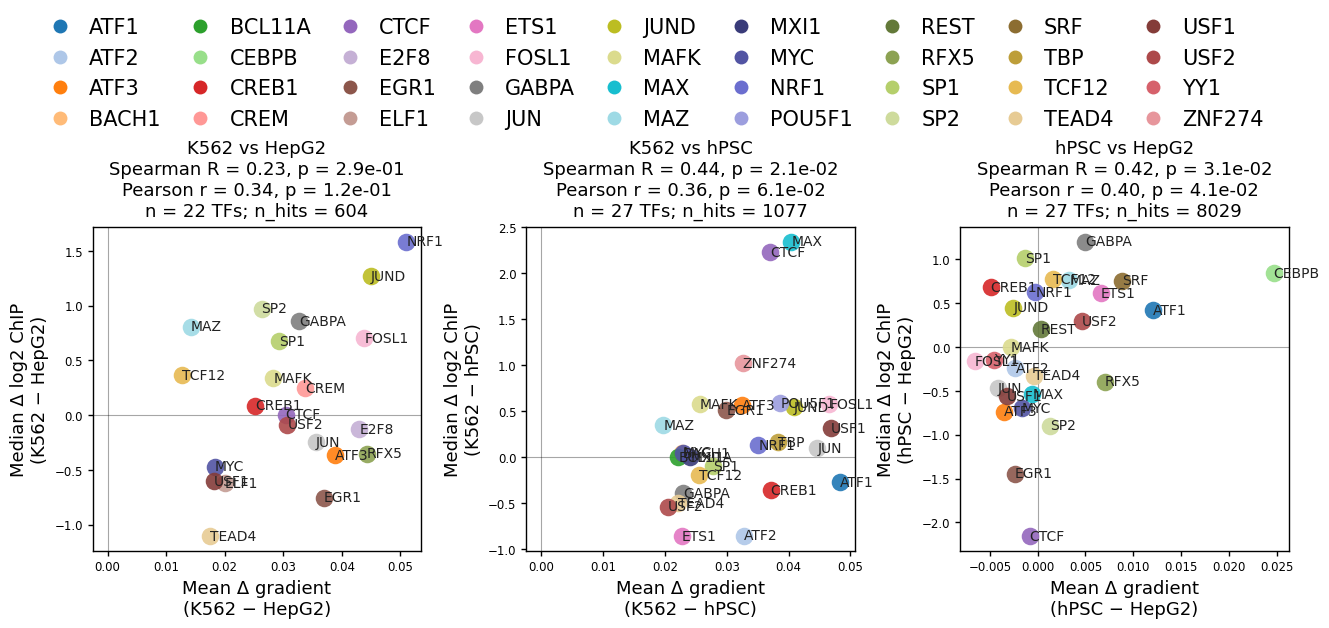

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from matplotlib.lines import Line2D
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
})
motif_df = pd.read_csv(
    "data/fig4/tf_mean_median_all_pairs.csv"
)
def get_pair_df(df, cl1, cl2):
    sub = df[
        (df["cl1"] == cl1) &
        (df["cl2"] == cl2)
    ].copy()
    if len(sub) == 0:
        sub = df[
            (df["cl1"] == cl2) &
            (df["cl2"] == cl1)
        ].copy()
        if len(sub) == 0:
            raise ValueError(f"No comparison found for {cl1} vs {cl2}")
        sub["agg_delta_grad"] = -sub["agg_delta_grad"]
        sub["agg_delta_chip_log2"] = -sub["agg_delta_chip_log2"]
        sub["cl1"] = cl1
        sub["cl2"] = cl2
    return sub
comparisons = [
    ("K562", "HepG2"),
    ("K562", "hPSC"),
    ("hPSC", "HepG2"),
]
pair_dfs = {}
for cl1, cl2 in comparisons:
    sub = get_pair_df(motif_df, cl1, cl2)
    sub = sub.dropna(
        subset=[
            "tf",
            "agg_delta_grad",
            "agg_delta_chip_log2",
            "n_hits",
        ]
    ).copy()
    pair_dfs[(cl1, cl2)] = sub
all_tfs = sorted(
    set(
        tf
        for sub in pair_dfs.values()
        for tf in sub["tf"].astype(str).unique()
    )
)
color_pool = (
    list(plt.cm.tab20.colors) +
    list(plt.cm.tab20b.colors) +
    list(plt.cm.tab20c.colors) +
    list(plt.cm.Set3.colors)
)
tf_color_dict = {
    tf: color_pool[i % len(color_pool)]
    for i, tf in enumerate(all_tfs)
}
def plot_tf_correlation_subplots(
    pair_dfs,
    comparisons,
    outdir="figures/tf_correlation_plots",
    filename_base="tf_corr_three_comparisons_by_tf",
    figsize=(13, 6),
    label_fontsize=10,
    point_size=160,
    dpi=300,
):
    os.makedirs(outdir, exist_ok=True)
    fig, axes = plt.subplots(
        1,
        len(comparisons),
        figsize=figsize,
        sharex=False,
        sharey=False,
    )
    if len(comparisons) == 1:
        axes = [axes]
    for ax, (cl1, cl2) in zip(axes, comparisons):
        sub = pair_dfs[(cl1, cl2)].copy()
        x = sub["agg_delta_grad"].values
        y = sub["agg_delta_chip_log2"].values
        spearman_r, spearman_p = spearmanr(x, y)
        pearson_r, pearson_p = pearsonr(x, y)
        n_tfs = sub["tf"].nunique()
        n_hits_total = int(sub["n_hits"].sum())
        for _, row in sub.iterrows():
            tf = str(row["tf"])
            ax.scatter(
                row["agg_delta_grad"],
                row["agg_delta_chip_log2"],
                s=point_size,
                c=[tf_color_dict[tf]],
                edgecolor="black",
                linewidth=0,
                alpha=0.9,
                zorder=3,
            )
        ax.axhline(
            0,
            color="black",
            linewidth=0.8,
            alpha=0.35,
            zorder=1,
        )
        ax.axvline(
            0,
            color="black",
            linewidth=0.8,
            alpha=0.35,
            zorder=1,
        )
        texts = []
        for _, row in sub.iterrows():
            tf = str(row["tf"])
            txt = ax.text(
                row["agg_delta_grad"],
                row["agg_delta_chip_log2"],
                tf,
                fontsize=label_fontsize,
                color="#222222",
                ha="left",
                va="center",
                zorder=3,
            )
            texts.append(txt)
        try:
            from adjustText import adjust_text
            adjust_text(
                texts,
                ax=ax,
                arrowprops=dict(
                    arrowstyle="-",
                    color="gray",
                    lw=0.35,
                    alpha=0.55,
                ),
                expand_points=(1.15, 1.25),
                expand_text=(1.08, 1.15),
                force_text=(0.35, 0.55),
                force_points=(0.15, 0.35),
            )
        except ImportError:
            print("adjustText not installed. Skipping label adjustment.")
        ax.set_title(
            (
                f"{cl1} vs {cl2}\n"
                f"Spearman R = {spearman_r:.2f}, p = {spearman_p:.1e}\n"
                f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.1e}\n"
                f"n = {n_tfs} TFs; n_hits = {n_hits_total}"
            ),
            fontsize=13,
            pad=8,
        )
        ax.set_xlabel(
            f"Mean Δ gradient\n({cl1} − {cl2})",
            fontsize=13,
        )
        ax.set_ylabel(
            f"Median Δ log2 ChIP\n({cl1} − {cl2})",
            fontsize=13,
        )
        ax.grid(False)
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)
        ax.tick_params(
            axis="both",
            labelsize=8.5,
        )
    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markersize=10,
            markerfacecolor=tf_color_dict[tf],
            markeredgecolor="black",
            markeredgewidth=0,
            label=tf,
        )
        for tf in all_tfs
    ]
    fig.legend(
        handles=legend_handles,
        labels=all_tfs,
        title="",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=min(9, len(all_tfs)),
        frameon=False,
        fontsize=15,
        title_fontsize=9,
        handletextpad=0.4,
        columnspacing=0.9,
        labelspacing=0.5,
    )
    fig.subplots_adjust(
        left=0.07,
        right=0.99,
        bottom=0.16,
        top=0.70,
        wspace=0.32,
    )
    pdf_path = os.path.join(outdir, filename_base + ".pdf")
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.savefig('figures/Fig4d_tf_correlation.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    
plot_tf_correlation_subplots(
    pair_dfs=pair_dfs,
    comparisons=comparisons,
)


# Figure 4f

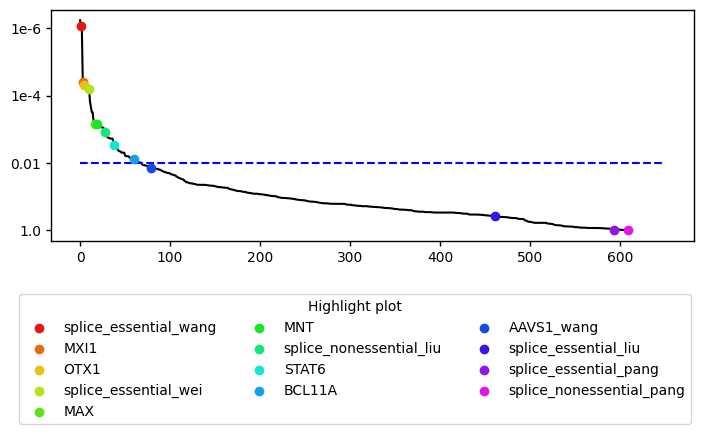

In [11]:
import colorsys
def hsv2rgb(h, s, v):
    """
    Python
    """
    h = max(0, min(360, h))
    s = max(0, min(1, s))
    v = max(0, min(1, v))
    r, g, b = colorsys.hsv_to_rgb(h/360.0, s, v)
    r = int(r * 255)
    g = int(g * 255)
    b = int(b * 255)
    return r, g, b
def hsv2hex(h, s=1.0, v=1.0, s_range=1.0, v_range=1.0, upper=False):
    """
    HSV
    :
        h (float): [0, 360]
        s (float): [0, 1] s_range
        v (float): [0, 1] v_range
        s_range (float): 1[0,1]100[0,100]
        v_range (float): 1[0,1]100[0,100]
        upper (bool): 
    :
        str: '#RRGGBB'
    :
        >>> hsv2hex(0, 1, 1)
        '#ff0000'
        >>> hsv2hex(120, 100, 100, s_range=100, v_range=100)
        '#00ff00'
        >>> hsv2hex(240, 50, 80, s_range=100, v_range=100, upper=True)
        '#6666CC'
    """
    if s_range != 1.0:
        s = s / s_range
    if v_range != 1.0:
        v = v / v_range
    h = max(0, min(360, h))
    s = max(0, min(1, s))
    v = max(0, min(1, v))
    r, g, b = colorsys.hsv_to_rgb(h/360.0, s, v)
    hex_color = f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}"
    if upper:
        hex_color = hex_color.upper()
    return hex_color
table = pd.read_csv('data/fig4/BER1.gene_summary.txt',sep = '\t')
table = table[['id','neg|score','pos|score']]
table['neg_tRRA'] = -np.log10(table[['neg|score']])
table['pos_tRRA'] = -np.log10(table[['pos|score']])
highlight_list = ['splice_essential_wang','splice_essential_wei','MXI1','OTX1','MNT','MAX','STAT6','BCL11A']
plt.figure(figsize=(8.3,3))
table = table.sort_values(by=['neg_tRRA'],ascending=False).reset_index(drop=True)
plt.plot([i for i in range(len(table))],table['neg_tRRA'],color='k')
count = 0
for rw in table.itertuples():
    if rw.id in highlight_list:
        plt.scatter(rw.Index,rw.neg_tRRA,label=rw.id,color=hsv2hex(count*25,0.9,0.9),zorder=3)
    elif 'essential' in rw.id:
        plt.scatter(rw.Index,rw.neg_tRRA,label=rw.id,color=hsv2hex(count*25,0.9,0.9),zorder=3)
    elif 'AAVS1' in rw.id:
        plt.scatter(rw.Index,rw.neg_tRRA,label=rw.id,color=hsv2hex(count*25,0.9,0.9),zorder=3)
    else:
        continue
    count += 1
plt.plot([0,650],[2,2],color='b',linestyle='--')
plt.yticks([0,2,4,6],['1.0','0.01','1e-4','1e-6'])
plt.legend(ncol=3,loc='upper left',bbox_to_anchor=(-0.06,-0.2),title='Highlight plot')
plt.savefig('figures/Fig4f_BE_rank.pdf', bbox_inches='tight', dpi=300)
plt.show()


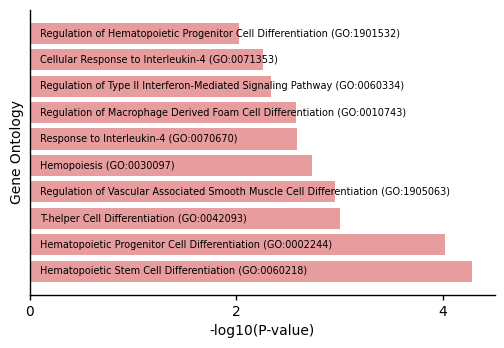

In [12]:
GeneSet = pd.read_csv(
    'data/fig4/BETF_select.txt',
    sep='\t'
).iloc[:10].reset_index()
plt.figure(figsize=(6, 3.7))
plt.barh(GeneSet['Term'], -np.log10(GeneSet['P-value']),color='#e79c9d')
plt.xticks([0,2,4]);plt.xlabel('-log10(P-value)')
plt.yticks([]);plt.ylabel('Gene Ontology')
for i in range(10):
    plt.text(x=0.1,y=i,s=GeneSet.loc[i,'Term'],va='center',fontsize=7)
plt.title('')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
plt.savefig('figures/BaseEditingGOenrichment_TF_1.pdf',dpi=300)
plt.savefig('figures/Fig4f_BE_GO.pdf', bbox_inches='tight', dpi=300)
plt.show()


# Figure 4g

## AMLmut4288

AMLmut4261 -> rs8109241 chr19 G A
AMLmut4265 -> rs12976475 chr19 G A
AMLmut4267 -> rs12985807 chr19 T A
AMLmut4269 -> rs12976493 chr19 G A
AMLmut4271 -> rs10420288 chr19 C G
AMLmut4275 -> rs9305048 chr19 G A
AMLmut4276 -> rs78992533 chr19 G A
AMLmut4278 -> rs45497896 chr19 T C
AMLmut4282 -> rs35975843 chr19 C G
AMLmut4283 -> rs45480298 chr19 A G
AMLmut4284 -> rs56957458 chr19 A T
AMLmut4285 -> rs45476192 chr19 A G
AMLmut4286 -> rs116687791 chr19 G A
AMLmut4287 -> rs1108015 chr19 T C
AMLmut4288 -> rs2286362 chr19 A G
AMLmut4289 -> rs545563523 chr19 G T
AMLmut4291 -> rs4808491 chr19 A T
AMLmut4293 -> rs4808494 chr19 C T
AMLmut4294 -> rs56331026 chr19 C G
AMLmut4295 -> rs148324061 chr19 A G
AMLmut4296 -> rs57493430 chr19 C T
AMLmut4297 -> rs75640276 chr19 G C
AMLmut4298 -> rs11666594 chr19 A G
AMLmut4299 -> rs184263561 chr19 C T
AMLmut4300 -> rs2079604 chr19 A C
AMLmut4302 -> rs7246341 chr19 A G
AMLmut4303 -> rs7246341 chr19 A G
AMLmut4304 -> rs28529466 chr19 C T
AMLmut4306 -> rs571861483

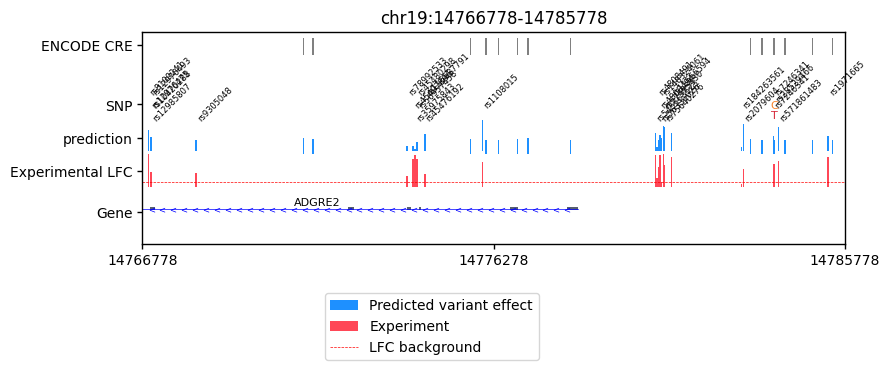

In [35]:
import pickle
with open('data/fig4/prep_AMLmut4288.pkl', 'rb') as f:
    p = pickle.load(f)
data = p['data']; VE = p['VE']; LFC = p['LFC']
ORI = p['ORI']; ALT = p['ALT']; AVG = p['AVG']
CHR = p['CHR']; START = p['START']
p1 = p['p1']; p2 = p['p2']
SNParound = p['SNParound']; CREaround = p['CREaround']
CREwt = p['CREwt']
VEc1 = p['VEc1']; VEc2 = p['VEc2']
LFCc1 = p['LFCc1']; LFCc2 = p['LFCc2']
LOCI_RS = p['LOCI_RS']
SNParound.to_csv('figures/AMLmut4288.csv')
fig = plt.figure(figsize=(9,4))
ax = plt.gca()

for _,rw in CREwt.iterrows():
    if rw['start']+200<START and START<rw['end']-200:
        rect = patches.Rectangle( (rw['start']+280, 4.0), 40, 0.5,edgecolor=None,facecolor='grey',alpha = 1.0,linewidth=1.5)
        ax.add_patch(rect)
    else:
        rect = patches.Rectangle( (rw['start']+280, 4.0),
                                  40,
                                  0.5,
                                  edgecolor=None,facecolor='grey',alpha = 1.0,linewidth=1.5)
        ax.add_patch(rect)
        rect = patches.Rectangle( (rw['start']+280, 1.0),
                                  40,
                                  sigmoid_norm( abs(rw['mut']-rw['wt']),VEc1,VEc2),
                                  edgecolor=None,facecolor='#1e90ff',alpha = 1.0,linewidth=1.5)
        ax.add_patch(rect)
SNParound = SNParound.groupby(['Gene','chr','ORISEQ','ALTSEQ']).agg({'LFC':'max','VE':'max','start':'mean'}).reset_index()
FLAG = 0
for _,rw in SNParound.iterrows():
    if rw.Gene.startswith('AMLmut'):
        c = rw.chr;s = rw.start-7;e=rw.start+7;a=rw.ORISEQ;b=rw.ALTSEQ
        q = LOCI_RS.query('chr == @c and start >= @s and start <= @e and ORISEQ == @a and ALTSEQ == @b')
        if len(q)>0:
            GENE = q['id'].values[0]
    else:
        GENE = rw.Gene
    print(rw.Gene,'->',GENE,c,a,b)
    if rw.Gene in ['AMLmut4304']:
        rect = patches.Rectangle( (rw['start']-20, 1.1),
                                  40,
                                  sigmoid_norm( VE,VEc1,VEc2 ),
                                  edgecolor=None,facecolor='#1e90ff',alpha = 1.0,linewidth=1.5,label='Predicted variant effect')
        ax.add_patch(rect)
        rect = patches.Rectangle( (rw['start']-20, 0.0),
                                  40,
                                  sigmoid_norm( LFC,LFCc1,LFCc2 ),
                                  edgecolor=None,facecolor='#ff4757',alpha = 1.0,linewidth=1.5,label='Experiment')
        ax.add_patch(rect)
        plt.text(x=rw.start,y=2.6,s=GENE,rotation=45,fontsize=6)
        plt.text(x=rw.start,y=2.4,s=rw.ORISEQ,fontsize=8,color=BASECOLOR[rw.ORISEQ],ha='center')
        plt.text(x=rw.start,y=2.1,s=rw.ALTSEQ,fontsize=8,color=BASECOLOR[rw.ALTSEQ],ha='center')
    elif rw['start']+200<START or START<rw['start']-200:
        rect = patches.Rectangle( (rw['start']-20, 1.1),
                                  40,
                                  sigmoid_norm( rw.VE,VEc1,VEc2 ),
                                  edgecolor=None,facecolor='#1e90ff',alpha = 1.0,linewidth=1.5)
        ax.add_patch(rect)
        rect = patches.Rectangle( (rw['start']-20, 0.0),
                                  40,
                                  sigmoid_norm( rw.LFC,LFCc1,LFCc2 ),
                                  edgecolor=None,facecolor='#ff4757',alpha = 1.0,linewidth=1.5)
        ax.add_patch(rect)
        plt.text(x=rw.start,y=2.8+FLAG,s=GENE,rotation=45,fontsize=6)
        FLAG -= 0.4
        if FLAG <= -1.2:
            FLAG = 0
        if False:
            plt.text(x=rw.start,y=1.4,s=rw.ORISEQ,fontsize=8,color=BASECOLOR[rw.ORISEQ],ha='center')
            plt.text(x=rw.start,y=1.1,s=rw.ALTSEQ,fontsize=8,color=BASECOLOR[rw.ALTSEQ],ha='center')
    else:
        pass
plt.plot([p1,p2],[sigmoid_norm( AVG,LFCc1,LFCc2 ),sigmoid_norm( AVG,LFCc1,LFCc2 )],linewidth=0.5,linestyle='--',color='r',label='LFC background')
if True:
    gene_df = p['gene_df']
    if len(gene_df)>0:
        draw_transcript(ax, gene_df, x_lim=[p1,p2], y_lim=[-1.5,-0.5], interval_base=64,intron_linewidth=0.5,gene_font_size=8,arrow_font_size=6)
    else:
        plt.text(x=(p1+p2)//2,y=-0.5,s='No any Gene',va='center',ha='center')
plt.xlim([p1,p2]);plt.xticks([p1,(p1+p2)//2,p2],[str(p1),str((p1+p2)//2),str(p2)])
plt.yticks([-0.75,0.5,1.5,2.5,4.3],['Gene','Experimental LFC','prediction','SNP','ENCODE CRE']);plt.ylim([-1.7,4.7])
plt.title(f'{CHR}:{p1}-{p2}')
plt.legend(loc='upper left',bbox_to_anchor=(0.25,-0.2))
plt.tight_layout()
plt.savefig(f'figures/AMLmut4288_20260615.pdf',dpi=300)
plt.show(fig)

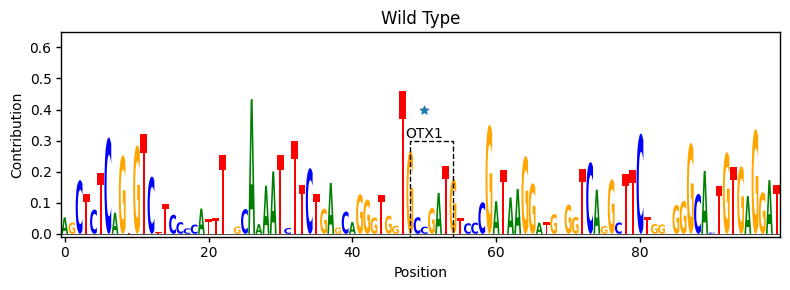

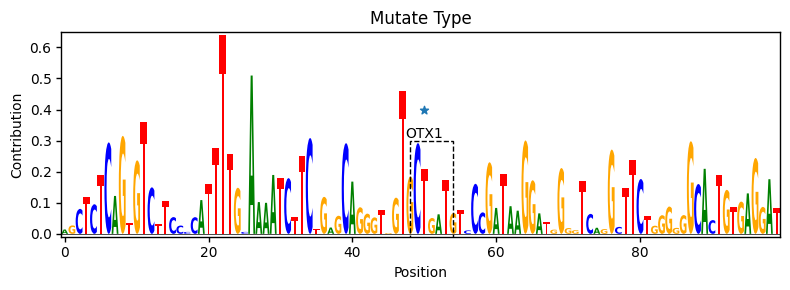

In [36]:
import logomaker
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
wt_weight = p['wt_weight']
mut_weight = p['mut_weight']
sequence = p['ig_sequence']
y_lim_bottom = min( min(wt_weight),min(mut_weight) )-0.01
y_lim_top    = max( max(wt_weight),max(mut_weight) )+0.01
df = pd.DataFrame(0.0, index=np.arange(len(sequence)), columns=list('ACGT'))
for pos, base in enumerate(sequence):
    if base in df.columns:
        df.loc[pos, base] = wt_weight[pos] if pos < len(wt_weight) else 0.0
fig, ax = plt.subplots(figsize=(8, 3))
logomaker.Logo(df, color_scheme='classic',ax=ax)
plt.scatter(50,0.4,marker='*')
rect = patches.Rectangle( (48, -0.3), 6, 0.6,edgecolor='k',facecolor='none',linewidth=1,linestyle='--')
ax.add_patch(rect)
plt.text(x=50,y=0.3,s='OTX1',rotation=0,fontsize=10,va='bottom',ha='center' )
plt.title(f"Wild Type")
plt.xlabel("Position")
plt.ylabel("Contribution")
plt.ylim([y_lim_bottom,y_lim_top])
plt.tight_layout()
plt.savefig('figures/rs936226-T_wt.pdf',dpi=300)
plt.show(fig)
sequence = p['ig_sequence_mut']
df = pd.DataFrame(0.0, index=np.arange(len(sequence)), columns=list('ACGT'))
for pos, base in enumerate(sequence):
    if base in df.columns:
        df.loc[pos, base] = mut_weight[pos] if pos < len(mut_weight) else 0.0
fig, ax = plt.subplots(figsize=(8, 3))
logomaker.Logo(df, color_scheme='classic',ax=ax)
plt.scatter(50,0.4,marker='*')
rect = patches.Rectangle( (48, -0.3), 6, 0.6,edgecolor='k',facecolor='none',linewidth=1,linestyle='--')
ax.add_patch(rect)
plt.text(x=50,y=0.3,s='OTX1',rotation=0,fontsize=10,va='bottom',ha='center' )
plt.title(f"Mutate Type")
plt.xlabel("Position")
plt.ylabel("Contribution")
plt.ylim([y_lim_bottom,y_lim_top])
plt.tight_layout()
plt.savefig('figures/rs936226-T_mut.pdf',dpi=300)
plt.show(fig)


## AMLmut9764

            Gene ORISEQ ALTSEQ       LFC        VE         start
0     AMLmut9763      G      A  2.612400  0.124088  1.329728e+08
1     AMLmut9764      A      C  1.438700 -0.152059  1.329737e+08
2     AMLmut9765      G      C  1.047700  0.420535  1.329738e+08
3     AMLmut9766      A      T  1.553900 -0.074382  1.329739e+08
4     AMLmut9767      C      T  5.519100  0.027621  1.329740e+08
5     AMLmut9768      G      A  0.053367 -0.401342  1.329741e+08
6     AMLmut9769      A      G  1.933700 -0.017016  1.329741e+08
7     AMLmut9770      T      C  1.508300 -0.203862  1.329742e+08
8     AMLmut9772      T      A  1.257600 -0.248674  1.329760e+08
9     AMLmut9773      A      G  1.820300 -0.126256  1.329760e+08
10    AMLmut9775      A      T  1.451100 -0.038647  1.329761e+08
11    AMLmut9776      T      A  1.625500  0.166982  1.329761e+08
12    AMLmut9778      T      C  0.566010 -0.059112  1.329778e+08
13    AMLmut9779      A      G  1.931600 -0.339770  1.329779e+08
14    AMLmut9780      G  

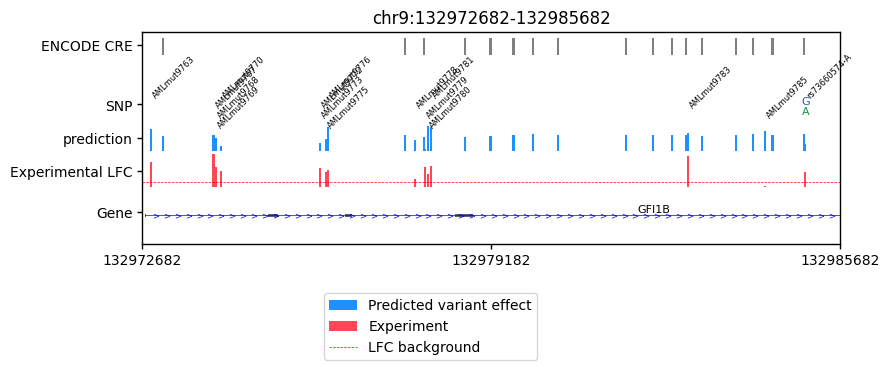

In [37]:
import pickle
with open('data/fig4/prep_AMLmut9764.pkl', 'rb') as f:
    p = pickle.load(f)
data = p['data']; VE = p['VE']; LFC = p['LFC']
ORI = p['ORI']; ALT = p['ALT']; AVG = p['AVG']
CHR = p['CHR']; START = p['START']
p1 = p['p1']; p2 = p['p2']
SNParound = p['SNParound']; CREaround = p['CREaround']
CREwt = p['CREwt']
VEc1 = p['VEc1']; VEc2 = p['VEc2']
LFCc1 = p['LFCc1']; LFCc2 = p['LFCc2']
LOCI_RS = p['LOCI_RS']
SNParound.to_csv('figures/AMLmut9764.csv')
fig = plt.figure(figsize=(9,4))
ax = plt.gca()

for _,rw in CREwt.iterrows():
    if rw['start']+200<START and START<rw['end']-200:
        rect = patches.Rectangle( (rw['start']+280, 4.0), 40, 0.5,edgecolor=None,facecolor='grey',alpha = 1.0,linewidth=1.5)
        ax.add_patch(rect)
    else:
        rect = patches.Rectangle( (rw['start']+280, 4.0),
                                  40,
                                  0.5,
                                  edgecolor=None,facecolor='grey',alpha = 1.0,linewidth=1.5)
        ax.add_patch(rect)
        rect = patches.Rectangle( (rw['start']+280, 1.1),
                                  40,
                                  sigmoid_norm( abs(rw['mut']-rw['wt']),VEc1,VEc2),
                                  edgecolor=None,facecolor='#1e90ff',alpha = 1.0,linewidth=1.5)
        ax.add_patch(rect)
SNParound = SNParound.groupby(['Gene','ORISEQ','ALTSEQ']).agg({'LFC':'max','VE':'max','start':'mean'}).reset_index()
print(SNParound.iloc[:50])
FLAG = 0
for _,rw in SNParound.iterrows():
    if rw.Gene in ['rs73660574-A']:
        rect = patches.Rectangle( (rw['start']-20, 1.1),
                                  40,
                                  sigmoid_norm( VE,VEc1,VEc2 ),
                                  edgecolor=None,facecolor='#1e90ff',alpha = 1.0,linewidth=1.5,label='Predicted variant effect')
        ax.add_patch(rect)
        rect = patches.Rectangle( (rw['start']-20, 0.0),
                                  40,
                                  sigmoid_norm( LFC,LFCc1,LFCc2 ),
                                  edgecolor=None,facecolor='#ff4757',alpha = 1.0,linewidth=1.5,label='Experiment')
        ax.add_patch(rect)
        plt.text(x=rw.start,y=2.7,s=rw.Gene,rotation=45,fontsize=6)
        plt.text(x=rw.start,y=2.5,s=rw.ORISEQ,fontsize=8,color=BASECOLOR[rw.ORISEQ],ha='center')
        plt.text(x=rw.start,y=2.2,s=rw.ALTSEQ,fontsize=8,color=BASECOLOR[rw.ALTSEQ],ha='center')
    elif rw['start']+200<START or START<rw['start']-200:
        rect = patches.Rectangle( (rw['start']-20, 1.1),
                                  40,
                                  sigmoid_norm( rw.VE,VEc1,VEc2 ),
                                  edgecolor=None,facecolor='#1e90ff',alpha = 1.0,linewidth=1.5)
        ax.add_patch(rect)
        rect = patches.Rectangle( (rw['start']-20, 0.0),
                                  40,
                                  sigmoid_norm( rw.LFC,LFCc1,LFCc2 ),
                                  edgecolor=None,facecolor='#ff4757',alpha = 1.0,linewidth=1.5)
        ax.add_patch(rect)
        plt.text(x=rw.start,y=2.7+FLAG,s=rw.Gene,rotation=45,fontsize=6)
        FLAG -= 0.3
        if FLAG <= -0.9:
            FLAG = 0
        if False:
            plt.text(x=rw.start,y=1.4,s=rw.ORISEQ,fontsize=8,color=BASECOLOR[rw.ORISEQ],ha='center')
            plt.text(x=rw.start,y=1.1,s=rw.ALTSEQ,fontsize=8,color=BASECOLOR[rw.ALTSEQ],ha='center')
    else:
        pass
plt.plot([p1,p2],[sigmoid_norm( AVG,LFCc1,LFCc2 ),sigmoid_norm( AVG,LFCc1,LFCc2 )],linewidth=0.5,linestyle='--',color='r',label='LFC background')
if True:
    gene_df = p['gene_df']
    if len(gene_df)>0:
        draw_transcript(ax, gene_df, x_lim=[p1,p2], y_lim=[-1.5,-0.5], interval_base=64,intron_linewidth=0.5,gene_font_size=8,arrow_font_size=6)
    else:
        plt.text(x=(p1+p2)//2,y=-0.5,s='No any Gene',va='center',ha='center')
plt.xlim([p1,p2]);plt.xticks([p1,(p1+p2)//2,p2],[str(p1),str((p1+p2)//2),str(p2)])
plt.yticks([-0.75,0.5,1.5,2.5,4.3],['Gene','Experimental LFC','prediction','SNP','ENCODE CRE']);plt.ylim([-1.7,4.7])
plt.title(f'{CHR}:{p1}-{p2}')
plt.legend(loc='upper left',bbox_to_anchor=(0.25,-0.2))
plt.tight_layout()
plt.savefig(f'figures/AMLmut9764_20260615.pdf',dpi=300)
plt.show(fig)


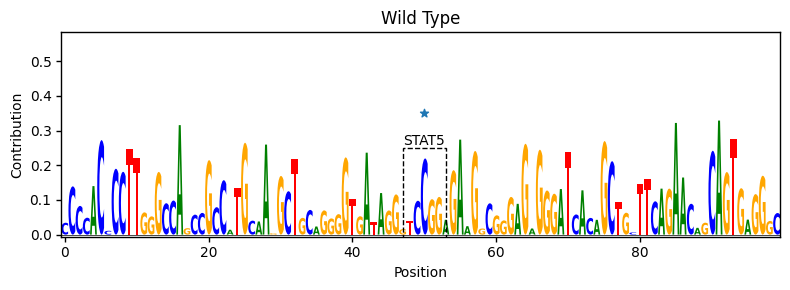

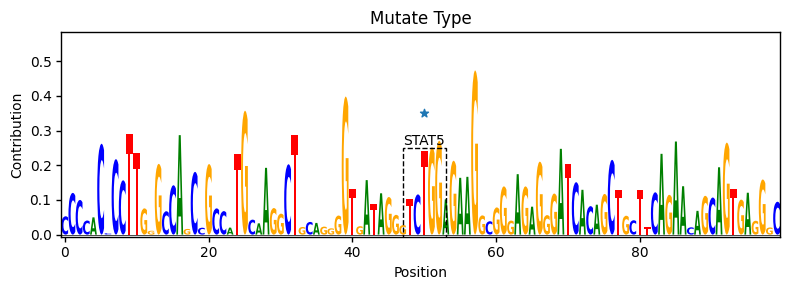

In [38]:
import logomaker
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
wt_weight = p['wt_weight']
mut_weight = p['mut_weight']
sequence = p['ig_sequence']
import logomaker
y_lim_bottom = min( min(wt_weight),min(mut_weight) )-0.01
y_lim_top    = max( max(wt_weight),max(mut_weight) )+0.01
df = pd.DataFrame(0.0, index=np.arange(len(sequence)), columns=list('ACGT'))
for pos, base in enumerate(sequence):
    if base in df.columns:
        df.loc[pos, base] = wt_weight[pos] if pos < len(wt_weight) else 0.0
fig, ax = plt.subplots(figsize=(8, 3))
logomaker.Logo(df, color_scheme='classic',ax=ax)
plt.scatter(50,0.35,marker='*')
rect = patches.Rectangle( (47, -0.25), 6, 0.5,edgecolor='k',facecolor='none',linewidth=1,linestyle='--')
ax.add_patch(rect)
plt.text(x=50,y=0.25,s='STAT5',rotation=0,fontsize=10,va='bottom',ha='center' )
plt.title(f"Wild Type")
plt.xlabel("Position")
plt.ylabel("Contribution")
plt.ylim([y_lim_bottom,y_lim_top+0.1])
plt.tight_layout()
plt.savefig('figures/rs73660574_wt.pdf',dpi=300)
plt.show(fig)
sequence = p['ig_sequence_mut']
df = pd.DataFrame(0.0, index=np.arange(len(sequence)), columns=list('ACGT'))
for pos, base in enumerate(sequence):
    if base in df.columns:
        df.loc[pos, base] = mut_weight[pos] if pos < len(mut_weight) else 0.0
fig, ax = plt.subplots(figsize=(8, 3))
logomaker.Logo(df, color_scheme='classic',ax=ax)
plt.scatter(50,0.35,marker='*')
rect = patches.Rectangle( (47, -0.25), 6, 0.5,edgecolor='k',facecolor='none',linewidth=1,linestyle='--')
ax.add_patch(rect)
plt.text(x=50,y=0.25,s='STAT5',rotation=0,fontsize=10,va='bottom',ha='center' )
plt.title(f"Mutate Type")
plt.xlabel("Position")
plt.ylabel("Contribution")
plt.ylim([y_lim_bottom,y_lim_top+0.1])
plt.tight_layout()
plt.savefig('figures/rs73660574_mut.pdf',dpi=300)
plt.show(fig)


# Figure 4h

PearsonRResult(statistic=np.float64(0.6735768539948599), pvalue=np.float64(6.022370514167189e-81))
SignificanceResult(statistic=np.float64(0.6825992132914035), pvalue=np.float64(6.572539436474086e-84))


/cluster2/huanglab/liquan/miniconda3/envs/shin/lib/python3.10/site-packages/matplotlib/text.py:905: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/cluster2/huanglab/liquan/miniconda3/envs/shin/lib/python3.10/site-packages/matplotlib/text.py:906: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
/cluster2/huanglab/liquan/miniconda3/envs/shin/lib/python3.10/site-packages/matplotlib/text.py:762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(x))
/cluster2/huanglab/liquan/miniconda3/envs/shin/lib/python3.10/site-packages/matplotlib/text.py:763: FutureWarning: Calling float on a single element

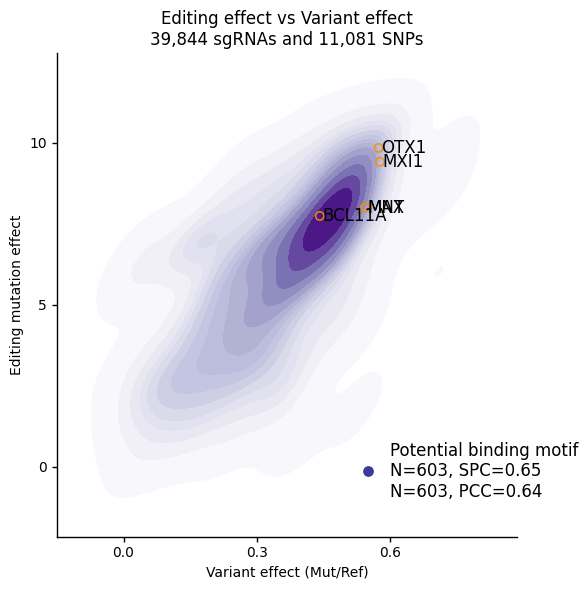

In [15]:
table = pd.read_csv('data/fig4/yLiu_BaseEditing.txt', sep='\t')
table['LFC'] = abs(table['LFC'])
table['VE']  = abs(table['VE'])
annot = pd.read_csv('data/fig4/annot_1.txt', sep='\t')
annot_table = pd.merge(annot,
                       table[['Gene','LFC','VE']].groupby(['Gene'],as_index=False).agg({'LFC':'max','VE':'max'}).rename(columns={'Gene':'id'}),
                       on=['id']
                      ).fillna('NoMotif')
motif_table = annot_table.groupby(['motif'],as_index=False).agg({'LFC':'max','VE':'max'})
print(pearsonr(abs(motif_table['LFC']), abs(motif_table['VE'])))
print(spearmanr(abs(motif_table['LFC']), abs(motif_table['VE'])))
import seaborn as sns
import matplotlib.pyplot as plt
df = motif_table.copy()
df['VE_norm']  = abs(motif_table['VE'])
df['LFC_norm'] = abs(motif_table['LFC'])
plt.figure(figsize=(6,6))
sns.kdeplot(
    data=df,
    x='VE_norm',
    y='LFC_norm',
    fill=True,
    cmap="Purples",
    thresh=0.01,
    levels=15,
    bw_adjust=1
)
x_annot = 0.55
motif_list = ['OTX1','MNT','MAX','BCL11A','MXI1']
for m in motif_list:
    X = df.loc[df['motif']==m,'VE_norm']
    Y = df.loc[df['motif']==m,'LFC_norm']
    plt.scatter(X,Y,color='darkorange',facecolor='none')
    plt.text(x=X+0.005,y=Y,s=m,va='center',ha='left',fontsize=12)
plt.scatter(
    [x_annot],[-0.15],
    s=45,color=['#3B3B98'],zorder=5
)
plt.text(x=x_annot+0.05,y=-0.15,
         s=f'Potential binding motif\nN=603, SPC=0.65\nN=603, PCC=0.64',
         va='center',ha='left',fontsize=12
        )
plt.xlabel('Variant effect (Mut/Ref)')
plt.ylabel('Editing mutation effect')
plt.title(
    f'Editing effect vs Variant effect\n'
    f'39,844 sgRNAs and 11,081 SNPs'
)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.grid(False)
plt.tight_layout()
plt.xticks([0, 0.3, 0.6])
plt.yticks([0, 5, 10])
plt.savefig('figures/Fig4h_scatter.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figures/Fig4h_scatter.pdf', bbox_inches='tight', dpi=300)
plt.show()


# Figure 4i

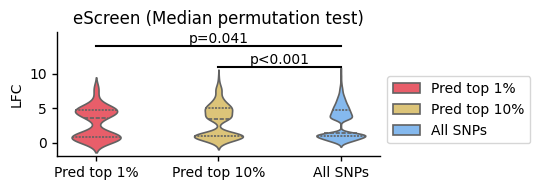

Bootstrap p-value (median difference): 0.04074
Bootstrap p-value (median difference): 0.00034


In [17]:
table = pd.read_csv('data/fig4/yLiu_BaseEditing.txt', sep='\t')
table['LFC'] = abs(table['LFC'])
table['VE']  = abs(table['VE'])
annot = pd.read_csv('data/fig4/annot_1.txt', sep='\t')
annot_table = pd.merge(annot,
                       (table[['Gene','LFC','VE']]
                        .groupby(['Gene'],as_index=False)
                        .agg({'LFC':'max','VE':'max'})
                        .rename(columns={'Gene':'id'})),
                       how='inner',
                       on=['id']
                      ).fillna('NoMotif')
table_adj = annot_table.copy()
cut_off_l = np.quantile(table_adj['LFC'],0.25)
cut_off_m = np.quantile(table_adj['LFC'],0.50)
cut_off_h = np.quantile(table_adj['LFC'],0.75)
cut_off_h1 = np.quantile(table_adj['VE'],0.90)
cut_off_h2 = np.quantile(table_adj['VE'],0.95)
cut_off_h3 = np.quantile(table_adj['VE'],0.99)
for rw in table_adj.itertuples():
    if rw.LFC <= cut_off_l:
        table_adj.at[rw.Index,'pool'] = 'low'
    elif rw.LFC >= cut_off_h:
        table_adj.at[rw.Index,'pool'] = 'high'
    else:
        if rw.LFC >= cut_off_m:
            table_adj.at[rw.Index,'pool'] = 'middle-high'
        else:
            table_adj.at[rw.Index,'pool'] = 'middle-low'
table_adj = table_adj[table_adj['pool'].isin(['high','low'])]
for rw in table_adj.itertuples():
    if rw.VE >= cut_off_h3:
        table_adj.at[rw.Index,'pool'] = 'highhighhigh'
    elif rw.VE >= cut_off_h2:
        table_adj.at[rw.Index,'pool'] = 'highhigh'
    elif rw.VE >= cut_off_h1:
        table_adj.at[rw.Index,'pool'] = 'high'
    else:
        table_adj.at[rw.Index,'pool'] = 'low'
low_lfc  = table_adj['LFC'].dropna()
high_lfc = table_adj.loc[table_adj['pool'].isin(['high','highhigh','highhighhigh']), 'LFC']
high_high_lfc = table_adj.loc[table_adj['pool'].isin(['highhigh','highhighhigh']), 'LFC']
high_high_high_lfc = table_adj.loc[table_adj['pool'].isin(['highhighhigh']), 'LFC']
x_grid = np.linspace(
    min(low_lfc.min(), high_lfc.min()),
    max(low_lfc.max(), high_lfc.max()),
    150
)
kde_low  = gaussian_kde(low_lfc,  bw_method=0.4)
kde_high = gaussian_kde(high_lfc, bw_method=0.4)
kde_high_high = gaussian_kde(high_high_lfc, bw_method=0.4)
kde_high_high_high = gaussian_kde(high_high_high_lfc, bw_method=0.4)

if True:
    data = pd.DataFrame({
        'Editing effect': np.concatenate([high_high_high_lfc, high_lfc, low_lfc, ]),
        'Group': ['Pred top 1%'] * len(high_high_high_lfc) + ['Pred top 10%'] * len(high_lfc) + ['All SNPs'] * len(low_lfc)
    })
else:
    pass
palette = {
    'All SNPs': '#74b9ff',
    'Other SNPs': '#74b9ff',
    'Pred top 10%': '#eccc68',
    'Pred top 1%': '#ff4757'
}
plt.figure(figsize=(4, 2.0))
sns.violinplot(
    data=data,
    x='Group',
    y='Editing effect',
    hue='Group',
    palette=palette,
    order=['Pred top 1%', 'Pred top 10%', 'All SNPs', ],
    linewidth=1.2,
    width=0.4,
    inner='quartile',
    legend=True
)
plt.xlabel('Group');plt.xlabel('')
plt.ylabel('LFC');plt.ylim([-2,16]);plt.yticks([0,5,10])
plt.title('eScreen (Median permutation test)')
plt.plot([0,2],[14.0,14.0],color='k')
plt.text(x=1.0,y=14.0,s='p=0.041',ha='center',va='bottom')
plt.plot([1,2],[11.0,11.0],color='k')
plt.text(x=1.5,y=11.0,s='p<0.001',ha='center',va='bottom')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/Fig4i_violin.pdf', dpi=300, bbox_inches='tight')
plt.legend(bbox_to_anchor=(1.0,0.7),loc='upper left')
plt.savefig('figures/Fig4i_violin.pdf', bbox_inches='tight', dpi=300)
plt.show()
n_bootstrap = 5000
obs_diff = np.median(high_high_high_lfc) - np.median(low_lfc)
combined = np.concatenate([high_high_high_lfc, low_lfc])
n1, n2 = len(high_high_high_lfc), len(low_lfc)
bootstrap_diffs = []
for _ in range(n_bootstrap):
    permuted = np.random.permutation(combined)
    diff = np.median(permuted[:n1]) - np.median(permuted[n1:])
    bootstrap_diffs.append(diff)
p_bootstrap = np.mean(np.abs(bootstrap_diffs) >= np.abs(obs_diff))
print(f"Bootstrap p-value (median difference): {p_bootstrap}")
obs_diff = np.median(high_lfc) - np.median(low_lfc)
combined = np.concatenate([high_lfc, low_lfc])
n1, n2 = len(high_lfc), len(low_lfc)
bootstrap_diffs = []
for _ in range(n_bootstrap):
    permuted = np.random.permutation(combined)
    diff = np.median(permuted[:n1]) - np.median(permuted[n1:])
    bootstrap_diffs.append(diff)
p_bootstrap = np.mean(np.abs(bootstrap_diffs) >= np.abs(obs_diff))
print(f"Bootstrap p-value (median difference): {p_bootstrap}")
